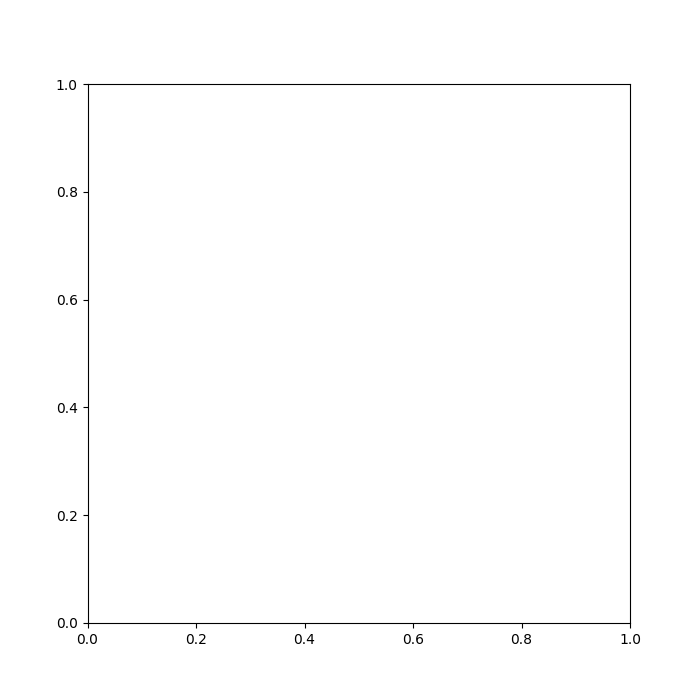

In [12]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

plt.ioff()
fig, ax = plt.subplots(figsize=(7, 7))
plt.ion()

slider_v_rocket = widgets.FloatSlider(value=2.4, min=0.5, max=5.0, step=0.1, description='Velocity Rocket:')
slider_v_plane = widgets.FloatSlider(value=1.3, min=0.5, max=5.0, step=0.1, description='Velocity Plane:')
btn_run = widgets.Button(description='Run Simulation', button_style='success', icon='play')
ui = widgets.VBox([widgets.HBox([slider_v_rocket, slider_v_plane]), btn_run])

ani = None
#constans
def chase_simulation(b):
    global ani
    if ani is not None:
        try:
            ani.event_source.stop()
        except:
            pass
        del ani
        ani = None
    ax.clear() 
    
    V_ROCKET = slider_v_rocket.value
    V_PLANE = slider_v_plane.value
    FRAMES = 300
    DT=0.1
    #set starting positions
    pos_city=np.array([12,12])
    pos_plane=np.array([12.0, 0.0])
    pos_rocket=np.array([2.0, 10.0])
    #history of movement
    history_plane = [pos_plane.copy()]
    history_rocket = [pos_rocket.copy()]
    curr_plane = pos_plane.copy()
    curr_rocket = pos_rocket.copy()
    plane_arrived = False
    rocket_hit_plane = False
    #movement - Euler Method
    for _ in range(FRAMES):
        vec_to_city = pos_city - curr_plane
        dist_to_city = np.linalg.norm(vec_to_city) 
        vec_to_plane = curr_plane - curr_rocket
        dist_to_plane = np.linalg.norm(vec_to_plane)
        if dist_to_plane < 0.3:
            status = "Rocket hit plane!"
            break
        if dist_to_city < 0.2:
            status = "Plane arrived!"
            break
        vel_plane = (vec_to_city / dist_to_city) * V_PLANE
        vel_rocket = (vec_to_plane / dist_to_plane) * V_ROCKET
        curr_plane += vel_plane * DT
        curr_rocket += vel_rocket * DT
        history_plane.append(curr_plane.copy())
        history_rocket.append(curr_rocket.copy())
    history_plane = np.array(history_plane)
    history_rocket = np.array(history_rocket)
    #chart
    ax.set_title("Simulation of a rocket chasing a plane")
    ax.set_xlim(-1, 15)
    ax.set_ylim(-1, 15)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_facecolor('lightblue')
    ax.plot(pos_city[0], pos_city[1], 'ks', markersize=15, markerfacecolor='black', label='CITY')
    rocket_trace, = ax.plot([], [], 'r-', linewidth=1.5, alpha=0.2, label='Rocket Trace')
    plane_dot, = ax.plot([], [], 'bo', markersize=8, label='PLANE', zorder=3)
    rocket_dot, = ax.plot([], [], 'ro', markersize=10, label='ROCKET', zorder=3)
    ax.legend(loc='upper left')
    #animation
    def animate(i):
        idx = min(i, len(history_plane) - 1)
        plane_dot.set_data([history_plane[idx, 0]], [history_plane[idx, 1]])
        rocket_dot.set_data([history_rocket[idx, 0]], [history_rocket[idx, 1]])
        rocket_trace.set_data(history_rocket[:idx+1, 0], history_rocket[:idx+1, 1])
        return plane_dot, rocket_dot, rocket_trace
    
    ani = FuncAnimation(fig, animate, frames=len(history_plane), interval=30, blit=True, repeat=False)
    fig.canvas.draw()

btn_run.on_click(chase_simulation)

display(ui)
display(fig.canvas)